# Is Expected Separation Calibrated?

R² and RMSE tell us how much route-to-route variation the model explains and how large its errors are. Calibration asks a different question: **when the model predicts a certain separation change, does that happen on average?** If routes predicted at -2 yards average -2 observed yards, that prediction range is calibrated.

We use the five-fold, game-grouped out-of-fold predictions for the current dynamic WR ridge model. Every route's prediction comes from a model that did not train on that route's game. This notebook measures route-level calibration; it does not establish that receiver residuals are stable or represent pure player skill.

In [1]:
from collections import defaultdict
from pathlib import Path
import random
import statistics
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import SVG, display
from separation_over_expected.reports import read_csv_rows

OOF_PATH = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "cross_validation" / "route_level_oof_predictions_wr.csv"
ROUTE_PATH = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "route_level_snap_to_release_dynamic.csv"
PREDICTION_COLUMN = "pred_delta_sep_ridge_dynamic_context"

oof_rows = read_csv_rows(OOF_PATH)
route_rows = read_csv_rows(ROUTE_PATH)
route_by_key = {(r["gameId"], r["playId"], r["nflId"]): r for r in route_rows}

rows = []
for row in oof_rows:
    context = route_by_key[(row["gameId"], row["playId"], row["nflId"])]
    observed = float(row["delta_sep"])
    predicted = float(row[PREDICTION_COLUMN])
    rows.append({
        **row,
        "observed": observed,
        "predicted": predicted,
        "residual": observed - predicted,
        "start_separation": float(context["sep_snap"]),
        "window_frames": float(context["time_to_throw_frames"]),
        "down_value": int(context["down"]),
    })

print(f"Game-grouped out-of-fold WR routes: {len(rows):,}")
print(f"Games represented: {len({r['gameId'] for r in rows}):,}")

Game-grouped out-of-fold WR routes: 20,415
Games represented: 122


## Overall calibration

A regression calibration line fits `observed = intercept + slope × predicted`. Ideal values are intercept 0 and slope 1. The overall residual mean should also be near 0. These summaries can look good while hiding local errors, so the next section checks prediction ranges and observable route contexts.

In [2]:
mean_predicted = statistics.fmean(r["predicted"] for r in rows)
mean_observed = statistics.fmean(r["observed"] for r in rows)
slope = sum((r["predicted"] - mean_predicted) * (r["observed"] - mean_observed) for r in rows) / sum((r["predicted"] - mean_predicted) ** 2 for r in rows)
intercept = mean_observed - slope * mean_predicted

overall_calibration = {
    "routes": len(rows),
    "mean_predicted_change_yards": round(mean_predicted, 3),
    "mean_observed_change_yards": round(mean_observed, 3),
    "mean_residual_yards": round(statistics.fmean(r["residual"] for r in rows), 3),
    "calibration_intercept_ideal_0": round(intercept, 3),
    "calibration_slope_ideal_1": round(slope, 3),
}
overall_calibration

{'routes': 20415,
 'mean_predicted_change_yards': -2.342,
 'mean_observed_change_yards': -2.341,
 'mean_residual_yards': 0.001,
 'calibration_intercept_ideal_0': -0.006,
 'calibration_slope_ideal_1': 0.997}

## Calibration by predicted range

Sort routes by predicted separation change and divide them into ten equally sized groups. For each group, compare its mean prediction with its mean observed change. Error bars use a game-cluster bootstrap: whole games are resampled together so routes from the same game are not treated as independent. The dashed diagonal is perfect calibration.

In [3]:
def make_prediction_bins(data, n_bins=10):
    ordered = sorted(data, key=lambda r: r["predicted"])
    result = []
    for index in range(n_bins):
        group = ordered[index * len(ordered) // n_bins : (index + 1) * len(ordered) // n_bins]
        result.append({
            "bin": index + 1,
            "rows": group,
            "n": len(group),
            "mean_predicted": statistics.fmean(r["predicted"] for r in group),
            "mean_observed": statistics.fmean(r["observed"] for r in group),
            "mean_residual": statistics.fmean(r["residual"] for r in group),
        })
    return result


calibration_bins = make_prediction_bins(rows)


def game_bootstrap_observed_intervals(data, bins, iterations=500, seed=42):
    # Keep bin membership fixed and resample games as clusters.
    aggregates = defaultdict(lambda: defaultdict(lambda: [0.0, 0.0, 0]))
    for bin_row in bins:
        bin_id = bin_row["bin"]
        for row in bin_row["rows"]:
            agg = aggregates[bin_id][row["gameId"]]
            agg[0] += row["observed"]
            agg[1] += row["observed"] - row["predicted"]
            agg[2] += 1
    game_ids = sorted({row["gameId"] for row in data})
    rng = random.Random(seed)
    samples = {bin_row["bin"]: [[], []] for bin_row in bins}
    for _ in range(iterations):
        draw = [rng.choice(game_ids) for _ in game_ids]
        for bin_row in bins:
            sums = [0.0, 0.0, 0]
            for game_id in draw:
                values = aggregates[bin_row["bin"]].get(game_id)
                if values:
                    sums[0] += values[0]
                    sums[1] += values[1]
                    sums[2] += values[2]
            if sums[2]:
                samples[bin_row["bin"]][0].append(sums[0] / sums[2])
                samples[bin_row["bin"]][1].append(sums[1] / sums[2])
    intervals = {}
    for bin_id, (observed_samples, residual_samples) in samples.items():
        observed_samples.sort()
        residual_samples.sort()
        intervals[bin_id] = {
            "observed_low": observed_samples[int(0.025 * len(observed_samples))],
            "observed_high": observed_samples[int(0.975 * len(observed_samples))],
            "residual_low": residual_samples[int(0.025 * len(residual_samples))],
            "residual_high": residual_samples[int(0.975 * len(residual_samples))],
        }
    return intervals


calibration_intervals = game_bootstrap_observed_intervals(rows, calibration_bins)
[
    {
        "prediction_decile": b["bin"],
        "routes": b["n"],
        "mean_predicted": round(b["mean_predicted"], 2),
        "mean_observed": round(b["mean_observed"], 2),
        "mean_residual": round(b["mean_residual"], 2),
        "game_bootstrap_observed_95%": (
            round(calibration_intervals[b["bin"]]["observed_low"], 2),
            round(calibration_intervals[b["bin"]]["observed_high"], 2),
        ),
    }
    for b in calibration_bins
]

[{'prediction_decile': 1,
  'routes': 2041,
  'mean_predicted': -5.89,
  'mean_observed': -5.79,
  'mean_residual': 0.1,
  'game_bootstrap_observed_95%': (-5.94, -5.64)},
 {'prediction_decile': 2,
  'routes': 2042,
  'mean_predicted': -4.52,
  'mean_observed': -4.53,
  'mean_residual': -0.01,
  'game_bootstrap_observed_95%': (-4.62, -4.42)},
 {'prediction_decile': 3,
  'routes': 2041,
  'mean_predicted': -3.71,
  'mean_observed': -3.75,
  'mean_residual': -0.04,
  'game_bootstrap_observed_95%': (-3.84, -3.66)},
 {'prediction_decile': 4,
  'routes': 2042,
  'mean_predicted': -3.01,
  'mean_observed': -3.08,
  'mean_residual': -0.07,
  'game_bootstrap_observed_95%': (-3.16, -3.0)},
 {'prediction_decile': 5,
  'routes': 2041,
  'mean_predicted': -2.39,
  'mean_observed': -2.38,
  'mean_residual': 0.01,
  'game_bootstrap_observed_95%': (-2.47, -2.29)},
 {'prediction_decile': 6,
  'routes': 2042,
  'mean_predicted': -1.81,
  'mean_observed': -1.75,
  'mean_residual': 0.06,
  'game_bootstrap

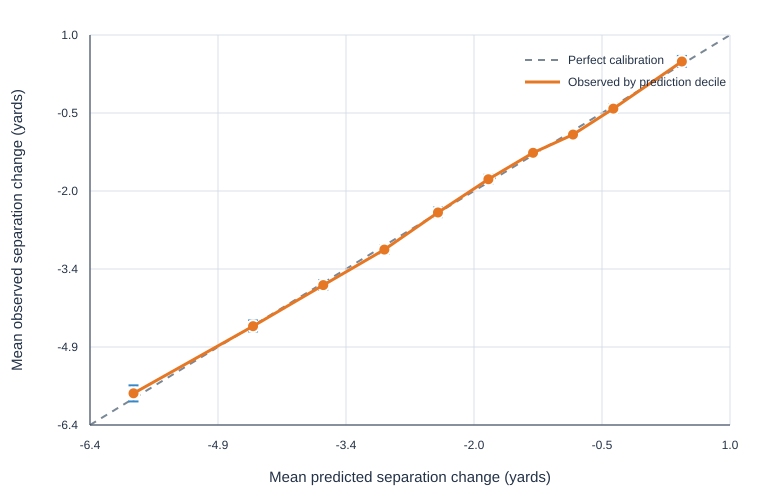

In [4]:
def svg_calibration_plot(bins, intervals, width=760, height=500):
    left, right, top, bottom = 90, 730, 35, 425
    all_values = [v for b in bins for v in (b["mean_predicted"], b["mean_observed"])]
    lo, hi = min(all_values) - 0.5, max(all_values) + 0.5
    def x(v): return left + (v - lo) / (hi - lo) * (right - left)
    def y(v): return bottom - (v - lo) / (hi - lo) * (bottom - top)
    pieces = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
              '<rect width="100%" height="100%" fill="white"/>',
              '<style>text{font-family:Arial,sans-serif;fill:#243247}.grid{stroke:#d9e0e8}.axis{stroke:#243247}.ideal{stroke:#7a8795;stroke-dasharray:7 6;stroke-width:2}.err{stroke:#3787c7;stroke-width:2}.curve{fill:none;stroke:#e67724;stroke-width:3}.dot{fill:#e67724;stroke:white;stroke-width:2}</style>',
              f'<line class="ideal" x1="{x(lo)}" y1="{y(lo)}" x2="{x(hi)}" y2="{y(hi)}"/>']
    ticks = [lo + i * (hi - lo) / 5 for i in range(6)]
    for v in ticks:
        pieces.append(f'<line class="grid" x1="{left}" y1="{y(v)}" x2="{right}" y2="{y(v)}"/>')
        pieces.append(f'<line class="grid" x1="{x(v)}" y1="{top}" x2="{x(v)}" y2="{bottom}"/>')
        pieces.append(f'<text x="{x(v)}" y="{bottom+24}" text-anchor="middle" font-size="12">{v:.1f}</text>')
        pieces.append(f'<text x="{left-12}" y="{y(v)+4}" text-anchor="end" font-size="12">{v:.1f}</text>')
    points = []
    for b in bins:
        xi, yi = x(b["mean_predicted"]), y(b["mean_observed"])
        ci = intervals[b["bin"]]
        pieces.append(f'<line class="err" x1="{xi}" y1="{y(ci["observed_low"])}" x2="{xi}" y2="{y(ci["observed_high"])}"/>')
        pieces.append(f'<line class="err" x1="{xi-5}" y1="{y(ci["observed_low"])}" x2="{xi+5}" y2="{y(ci["observed_low"])}"/>')
        pieces.append(f'<line class="err" x1="{xi-5}" y1="{y(ci["observed_high"])}" x2="{xi+5}" y2="{y(ci["observed_high"])}"/>')
        points.append(f'{xi},{yi}')
        pieces.append(f'<circle class="dot" cx="{xi}" cy="{yi}" r="6"><title>Decile {b["bin"]}: predicted {b["mean_predicted"]:.2f}, observed {b["mean_observed"]:.2f}</title></circle>')
    pieces.append(f'<polyline class="curve" points="{" ".join(points)}"/>')
    pieces.extend([
        f'<line class="axis" x1="{left}" y1="{bottom}" x2="{right}" y2="{bottom}"/>',
        f'<line class="axis" x1="{left}" y1="{top}" x2="{left}" y2="{bottom}"/>',
        f'<text x="{(left+right)/2}" y="{height-18}" text-anchor="middle" font-size="15">Mean predicted separation change (yards)</text>',
        f'<text x="22" y="{(top+bottom)/2}" text-anchor="middle" font-size="15" transform="rotate(-90 22 {(top+bottom)/2})">Mean observed separation change (yards)</text>',
        '<line class="ideal" x1="525" y1="60" x2="560" y2="60"/><text x="568" y="64" font-size="12">Perfect calibration</text>',
        '<line class="curve" x1="525" y1="82" x2="560" y2="82"/><text x="568" y="86" font-size="12">Observed by prediction decile</text>',
        '</svg>'
    ])
    return "".join(pieces)


display(SVG(svg_calibration_plot(calibration_bins, calibration_intervals)))

## Does calibration vary with route context?

Overall calibration can hide offsetting errors. Here we group routes into quintiles by starting separation and by observed input duration, then plot mean residual (`observed - predicted`). Values around zero indicate little average bias in that slice. These subgroup averages are diagnostic descriptions; the displayed points do not include confidence intervals.

In [5]:
def quantile_groups(data, field, n_groups=5):
    ordered = sorted(data, key=lambda r: r[field])
    groups = []
    for index in range(n_groups):
        group = ordered[index * len(ordered) // n_groups : (index + 1) * len(ordered) // n_groups]
        groups.append({
            "group": index + 1,
            "n": len(group),
            "mean_context": statistics.fmean(r[field] for r in group),
            "mean_residual": statistics.fmean(r["residual"] for r in group),
        })
    return groups


context_bins = {
    "Starting separation (yd)": quantile_groups(rows, "start_separation"),
    "Input-window duration (frames)": quantile_groups(rows, "window_frames"),
}
context_bins

{'Starting separation (yd)': [{'group': 1,
   'n': 4083,
   'mean_context': 2.201636051922606,
   'mean_residual': 0.008147403328434976},
  {'group': 2,
   'n': 4083,
   'mean_context': 3.5025664952241,
   'mean_residual': 0.035826937937790834},
  {'group': 3,
   'n': 4083,
   'mean_context': 5.24874283614989,
   'mean_residual': 0.03334245905706588},
  {'group': 4,
   'n': 4083,
   'mean_context': 6.858510164095028,
   'mean_residual': -0.12302245930198383},
  {'group': 5,
   'n': 4083,
   'mean_context': 9.090028410482489,
   'mean_residual': 0.05049916938525595}],
 'Input-window duration (frames)': [{'group': 1,
   'n': 4083,
   'mean_context': 18.80333088415381,
   'mean_residual': 0.15158348546411954},
  {'group': 2,
   'n': 4083,
   'mean_context': 23.477590007347537,
   'mean_residual': -0.10887050610335537},
  {'group': 3,
   'n': 4083,
   'mean_context': 27.155767817781044,
   'mean_residual': -0.1135168942811658},
  {'group': 4,
   'n': 4083,
   'mean_context': 31.72495713935

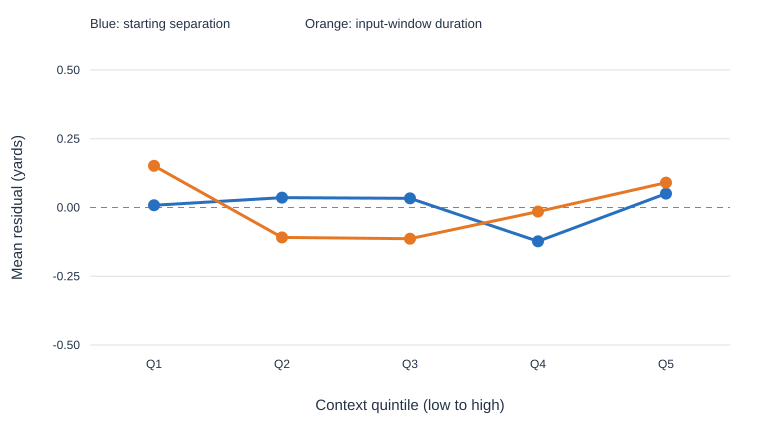

In [6]:
def svg_context_bias_plot(context_bins, width=760, height=430):
    left, right, top, bottom = 90, 730, 70, 345
    values = [g["mean_residual"] for groups in context_bins.values() for g in groups]
    limit = max(0.5, max(abs(v) for v in values) * 1.2)
    def y(v): return bottom - (v + limit) / (2 * limit) * (bottom - top)
    pieces = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
              '<rect width="100%" height="100%" fill="white"/>',
              '<style>text{font-family:Arial,sans-serif;fill:#243247}.grid{stroke:#d9e0e8}.zero{stroke:#7a8795;stroke-dasharray:6 5}.line{fill:none;stroke:#276fbf;stroke-width:3}.dot{fill:#276fbf;stroke:white;stroke-width:2}</style>',
              f'<text x="{left}" y="28" font-size="13">Blue: starting separation</text>',
              f'<text x="{left+215}" y="28" font-size="13" fill="#e67724">Orange: input-window duration</text>']
    for tick in range(-2, 3):
        v = tick * limit / 2
        pieces.append(f'<line class="{"zero" if tick == 0 else "grid"}" x1="{left}" y1="{y(v)}" x2="{right}" y2="{y(v)}"/>')
        pieces.append(f'<text x="{left-10}" y="{y(v)+4}" text-anchor="end" font-size="12">{v:.2f}</text>')
    colors = ["#276fbf", "#e67724"]
    for series_index, (label, groups) in enumerate(context_bins.items()):
        points = []
        for g in groups:
            xi = left + (g["group"] - 0.5) * (right - left) / 5
            yi = y(g["mean_residual"])
            points.append(f"{xi},{yi}")
            pieces.append(f'<circle cx="{xi}" cy="{yi}" r="6" fill="{colors[series_index]}"><title>{label}, group {g["group"]}: residual {g["mean_residual"]:.3f} yd, n={g["n"]}</title></circle>')
        pieces.append(f'<polyline points="{" ".join(points)}" fill="none" stroke="{colors[series_index]}" stroke-width="3"/>')
    for i in range(5):
        xi = left + (i + 0.5) * (right - left) / 5
        pieces.append(f'<text x="{xi}" y="{bottom+23}" text-anchor="middle" font-size="12">Q{i+1}</text>')
    pieces.extend([
        f'<text x="{(left+right)/2}" y="{height-20}" text-anchor="middle" font-size="15">Context quintile (low to high)</text>',
        f'<text x="22" y="{(top+bottom)/2}" text-anchor="middle" font-size="15" transform="rotate(-90 22 {(top+bottom)/2})">Mean residual (yards)</text>',
        '</svg>'
    ])
    return "".join(pieces)


display(SVG(svg_context_bias_plot(context_bins)))

## What this says about the model

Calibration is strong overall if the decile points track the diagonal and the overall slope/intercept are near 1/0. Small context-specific residual patterns are still worth monitoring, especially because route groups may differ in unobserved ways. Good calibration supports interpreting `observed - expected` as a meaningful *context-adjusted route residual*; it does not by itself prove the residual is a stable receiver trait. That requires the separate game- and season-level reliability checks.

In this run, overall calibration is close to ideal: the mean prediction is -2.342 yards versus -2.341 observed, the mean residual is +0.001 yards, and the calibration slope/intercept are 0.997/-0.006. Across prediction deciles, average residuals range from about -0.07 to +0.10 yards. Context-slice mean residuals are also small (within about 0.16 yards for starting-separation quintiles and 0.16 yards for window-duration quintiles). This supports the model as a route-level expected-separation baseline, while leaving receiver-level reliability as a separate question.